In [1]:
import Pkg; Pkg.add("ITensors")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\AVM11\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\AVM11\.julia\environments\v1.12\Manifest.toml`


In [2]:
using DelimitedFiles
using Pkg
Pkg.activate("../")  # Activate the main project
using Dleto
using Random
using ITensors
using Statistics
using Plots

  Activating project at `c:\Users\AVM11\GitHub\OpenDleto`


WebIO._IJuliaInit()

Loading Dleto Plots Extension


In [3]:

function process_high_school_hypergraph(k::Int; seed::Union{Int,Nothing}=nothing)
    # Load the contact-high-school temporal hypergraph dataset


    # Load the three data files
    nverts_file = "contact-high-school/contact-high-school-nverts.txt"
    simplices_file = "contact-high-school/contact-high-school-simplices.txt"
    times_file = "contact-high-school/contact-high-school-times.txt"

    # Read number of vertices per simplex
    nverts_full = vec(readdlm(nverts_file, Int))
    println("Total number of simplices: ", length(nverts_full))

    # Read all simplex node IDs (contiguous list)
    all_nodes_full = vec(readdlm(simplices_file, Int))
    println("Total node entries: ", length(all_nodes_full))

    # Read timestamps
    timestamps_full = vec(readdlm(times_file, Int))
    println("Total timestamps: ", length(timestamps_full))

    # Filter to random k nodes only
    all_unique_nodes = sort(unique(all_nodes_full))
    if seed !== nothing
        Random.seed!(seed)
        println("Random seed set to $seed")
    end
    random_k_nodes = Set(shuffle(all_unique_nodes)[1:k])
    println("Filtering to random $k nodes: $(sort(collect(random_k_nodes)))")

    # Filter simplices to only include those with all nodes in random_k_nodes
    filtered_indices = Int[]
    node_idx = 1
    for (simplex_idx, nvert) in enumerate(nverts_full)
        simplex_nodes = all_nodes_full[node_idx:(node_idx + nvert - 1)]
        if all(node in random_k_nodes for node in simplex_nodes)
            push!(filtered_indices, simplex_idx)
        end
        node_idx += nvert
    end

    # Create filtered datasets
    nverts = nverts_full[filtered_indices]
    timestamps = timestamps_full[filtered_indices]

    # Rebuild all_nodes for filtered simplices
    all_nodes = Int[]
    for simplex_idx in filtered_indices
        nvert = nverts_full[simplex_idx]
        orig_pos = sum(nverts_full[1:simplex_idx-1]) + 1
        simplex_nodes = all_nodes_full[orig_pos:(orig_pos + nvert - 1)]
        append!(all_nodes, simplex_nodes)
    end
    max_view = length(unique(all_nodes))
    println("\nFiltered dataset statistics:")
    println("Number of timestamped simplices: ", length(nverts))
    println("Number of unique node IDs: ", length(unique(all_nodes)))
    println("Simplex size distribution:")
    size_counts = Dict{Int, Int}()
    for size in nverts
        size_counts[size] = get(size_counts, size, 0) + 1
    end
    for size in sort(collect(keys(size_counts)))
        count = size_counts[size]
        println("  Size $size: $count simplices")
    end

    # Parse simplices from the contiguous node list
    simplices = Vector{Vector{Int}}()
    node_idx = 1
    for nvert in nverts
        simplex_nodes = all_nodes[node_idx:(node_idx + nvert - 1)]
        push!(simplices, simplex_nodes)
        node_idx += nvert
    end
    println("Parsed ", length(simplices), " simplices")
    println("First few simplices:")
    for i in 1:min(10, length(simplices))
        println("  Simplex $i (time $(timestamps[i])): $(simplices[i])")
    end

    # Create simple temporal simplex structure for processing
    temporal_simplices = [(simplices[i], timestamps[i], nverts[i]) for i in 1:length(simplices)]
    println("Created temporal hypergraph with ", length(temporal_simplices), " temporal simplices")

    # Basic statistics
    all_unique_nodes = sort(unique(all_nodes))
    println("Number of nodes: ", length(all_unique_nodes))
    println("Time range: $(minimum(timestamps)) to $(maximum(timestamps))")
    println("\nReady for tensor creation!")

    # Create a 3-mode tensor by decomposing hyperedges into 3-node subsets
    println("Creating 3-mode tensor from hyperedge decomposition ($k nodes only)...")
    unique_nodes = all_unique_nodes[1:max_view]
    node_to_idx = Dict(node => i for (i, node) in enumerate(unique_nodes))
    n_nodes = max_view
    println("Tensor dimensions:")
    println("  Node 1: $n_nodes")
    println("  Node 2: $n_nodes")
    println("  Node 3: $n_nodes")
    println("  Total entries: $(n_nodes^3)")
    println("  Using nodes: $(minimum(unique_nodes)) to $(maximum(unique_nodes))")

    function get_3node_combinations(nodes)
        if length(nodes) < 3
            return []
        elseif length(nodes) == 3
            return [nodes]
        else
            combinations = []
            for i in 1:length(nodes)-2
                for j in i+1:length(nodes)-1
                    for k in j+1:length(nodes)
                        push!(combinations, [nodes[i], nodes[j], nodes[k]])
                    end
                end
            end
            return combinations
        end
    end

    # Create ITensor indices for the 3-mode tensor
    i = Index(n_nodes, "node1")
    j = Index(n_nodes, "node2")
    k = Index(n_nodes, "node3")
    Triangles = ITensor(Float32, i, j, k)

    # Populate the tensor by counting 3-node combinations
    processed_simplices = 0
    total_triangles = 0
    skipped_small = 0
    for (idx, ts) in enumerate(temporal_simplices)
        triangle_combinations = get_3node_combinations(ts[1]) # ts[1] is the nodes vector
        if isempty(triangle_combinations)
            skipped_small += 1
            continue
        end
        for triangle in triangle_combinations
            node_indices = []
            for node in triangle
                if node in keys(node_to_idx) # Double check that all nodes are within our random sample
                    push!(node_indices, node_to_idx[node])
                end
            end
            if length(node_indices) == 3
                a, b, c = node_indices[1], node_indices[2], node_indices[3]
                Triangles[i=>a, j=>b, k=>c] += 1.0
                Triangles[i=>a, j=>c, k=>b] += 1.0
                Triangles[i=>b, j=>a, k=>c] += 1.0
                Triangles[i=>b, j=>c, k=>a] += 1.0
                Triangles[i=>c, j=>a, k=>b] += 1.0
                Triangles[i=>c, j=>b, k=>a] += 1.0
                total_triangles += 1
            end
        end
        processed_simplices += 1
    end

    # Analyze the tensor
    T_array = Array(Triangles, i, j, k)
    non_zero_entries = count(x -> x != 0, T_array)
    total_entries = length(T_array)
    println("✅ 3-mode triangle tensor created!")
    println("Processed simplices: $processed_simplices")
    println("Skipped simplices (< 3 nodes): $skipped_small")
    println("Total triangles extracted: $total_triangles")
    println("Non-zero tensor entries: $non_zero_entries / $total_entries")
    println("Sparsity: $(round((total_entries - non_zero_entries) / total_entries * 100, digits=1))%")
    println("Max triangle count: $(Int(maximum(T_array)))")
    println("Mean triangle count: $(round(mean(T_array[T_array .> 0]), digits=2))")

    # Plot the tensor
    # plot_tensor(Triangles, title="High School Contact Triangle Tensor")

    # Create a k×k×k subsample tensor for faster processing
    println("Creating $k×$k×$k subsample tensor...")
    max = max_view
    i_small = Index(max, "node1_small")
    j_small = Index(max, "node2_small")
    k_small = Index(max, "node3_small")
    SmallHigh = ITensor(i_small, j_small, k_small)
    T_small_array = T_array[1:max, 1:max, 1:max]
    for a in 1:max, b in 1:max, c in 1:max
        if T_small_array[a, b, c] != 0
            SmallHigh[i_small=>a, j_small=>b, k_small=>c] = T_small_array[a, b, c]
        end
    end
    small_non_zero = count(x -> x != 0, T_small_array)
    small_total = length(T_small_array)
    println("✅ Subsample tensor created!")

    # Perform stratified decomposition on the subsample
    println("\n🔬 Performing stratified decomposition on SmallHigh tensor...")
    @time SmallHigh_strat, Xs_strat_small = stratify(SmallHigh)
    println("✅ SmallHigh stratification complete!")

    # Plot SmallHigh and SmallHigh_strat side by side
    p1 = plot_tensor(SmallHigh; title="Original SmallHigh", color=:blue)
    p2 = plot_tensor(SmallHigh_strat; title="Stratified SmallHigh", color=:red)
    Plots.plot(p1, p2; layout=(1,2), size=(800,400))

end

process_high_school_hypergraph (generic function with 1 method)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 50 nodes: [10, 23, 28, 32, 35, 68, 71, 74, 86, 89, 93, 94, 107, 121, 132, 135, 137, 144, 145, 148, 158, 164, 180, 181, 187, 208, 211, 213, 215, 225, 232, 234, 235, 236, 244, 249, 263, 266, 273, 276, 279, 280, 281, 287, 291, 294, 295, 299, 306, 325]

Filtered dataset statistics:
Number of timestamped simplices: 1711
Number of unique node IDs: 50
Simplex size distribution:
  Size 2: 1702 simplices
  Size 3: 9 simplices
Parsed 1711 simplices
First few simplices:
  Simplex 1 (time 1385982300): [71, 93]
  Simplex 2 (time 1385982320): [32, 121]
  Simplex 3 (time 1385982320): [86, 28]
  Simplex 4 (time 1385982400): [32, 121]
  Simplex 5 (time 1385982480): [145, 144]
  Simplex 6 (time 1385982580): [71, 107]
  Simplex 7 (time 1385982660): [93, 107]
  Simplex 8 (time 1385982820): [215, 213]
  Simplex 9 (time 1385982920): [132, 181]
  Simplex 10 (time 1385982920): [35, 244]
Created temporal h

[ Info: Found 10 derivations for stratification.


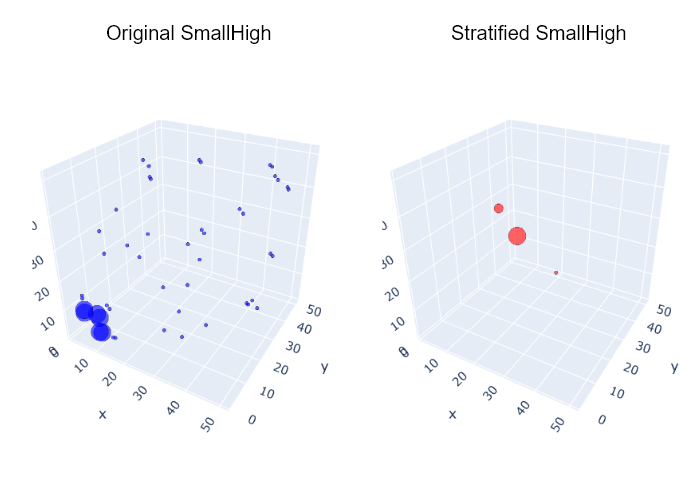

In [ ]:
process_high_school_hypergraph(50)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 50 nodes: [3, 4, 10, 11, 39, 42, 43, 47, 60, 63, 74, 78, 80, 81, 82, 89, 99, 105, 107, 120, 125, 130, 138, 153, 155, 158, 159, 164, 165, 171, 183, 186, 206, 211, 222, 223, 233, 238, 240, 244, 247, 250, 270, 283, 285, 290, 297, 311, 313, 320]

Filtered dataset statistics:
Number of timestamped simplices: 2892
Number of unique node IDs: 49
Simplex size distribution:
  Size 2: 2869 simplices
  Size 3: 23 simplices
Parsed 2892 simplices
First few simplices:
  Simplex 1 (time 1385982020): [4, 3]
  Simplex 2 (time 1385982040): [4, 3]
  Simplex 3 (time 1385982060): [4, 3]
  Simplex 4 (time 1385982060): [80, 81]
  Simplex 5 (time 1385982080): [10, 11]
  Simplex 6 (time 1385982080): [4, 3]
  Simplex 7 (time 1385982100): [4, 3]
  Simplex 8 (time 1385982120): [4, 3]
  Simplex 9 (time 1385982140): [4, 3]
  Simplex 10 (time 1385982160): [4, 3]
Created temporal hypergraph with 2892 temporal simp

[ Info: Found 10 derivations for stratification.


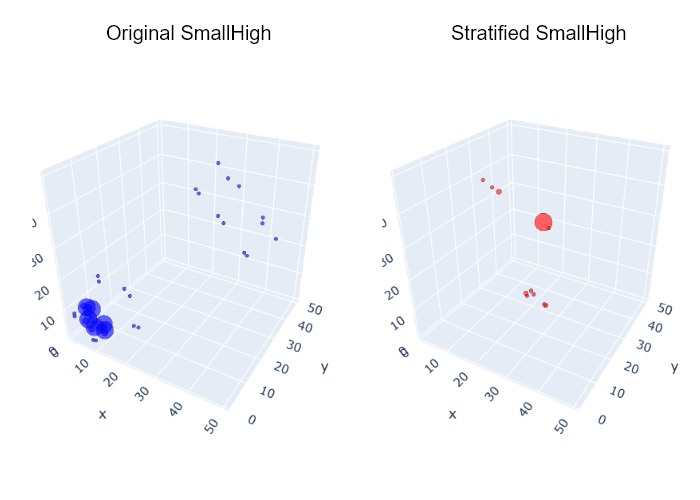

In [ ]:
process_high_school_hypergraph(50)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 50 nodes: [10, 30, 34, 36, 39, 45, 53, 55, 57, 59, 72, 82, 93, 99, 100, 118, 130, 131, 135, 143, 146, 150, 151, 154, 159, 174, 184, 192, 198, 202, 205, 210, 218, 220, 221, 233, 236, 249, 255, 256, 266, 267, 276, 281, 300, 306, 312, 313, 323, 326]

Filtered dataset statistics:
Number of timestamped simplices: 2655
Number of unique node IDs: 49
Simplex size distribution:
  Size 2: 2634 simplices
  Size 3: 21 simplices
Parsed 2655 simplices
First few simplices:
  Simplex 1 (time 1385982220): [93, 39]
  Simplex 2 (time 1385982380): [99, 72]
  Simplex 3 (time 1385982460): [143, 39]
  Simplex 4 (time 1385982540): [99, 72]
  Simplex 5 (time 1385982560): [99, 72]
  Simplex 6 (time 1385982580): [99, 72]
  Simplex 7 (time 1385982640): [99, 72]
  Simplex 8 (time 1385982660): [99, 72]
  Simplex 9 (time 1385982720): [59, 118]
  Simplex 10 (time 1385982720): [57, 30]
Created temporal hypergraph 

[ Info: Found 10 derivations for stratification.


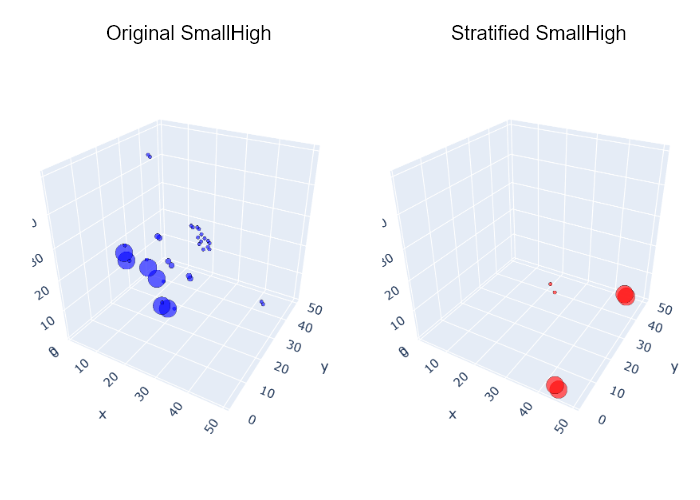

In [ ]:
process_high_school_hypergraph(50)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 60 nodes: [2, 16, 19, 26, 27, 31, 36, 41, 42, 47, 68, 70, 85, 92, 93, 94, 111, 113, 120, 121, 122, 126, 127, 131, 139, 140, 142, 155, 173, 179, 180, 188, 192, 194, 198, 205, 217, 225, 229, 231, 235, 237, 243, 244, 251, 258, 260, 261, 263, 268, 269, 277, 288, 290, 293, 300, 304, 309, 317, 320]

Filtered dataset statistics:
Number of timestamped simplices: 6237
Number of unique node IDs: 60
Simplex size distribution:
  Size 2: 6192 simplices
  Size 3: 45 simplices
Parsed 6237 simplices
First few simplices:
  Simplex 1 (time 1385982020): [42, 41]
  Simplex 2 (time 1385982040): [42, 41]
  Simplex 3 (time 1385982060): [42, 41]
  Simplex 4 (time 1385982080): [42, 41]
  Simplex 5 (time 1385982100): [42, 41]
  Simplex 6 (time 1385982120): [42, 41]
  Simplex 7 (time 1385982140): [42, 85]
  Simplex 8 (time 1385982140): [42, 41]
  Simplex 9 (time 1385982160): [42, 85]
  Simplex 10 (time 13859

[ Info: Found 10 derivations for stratification.


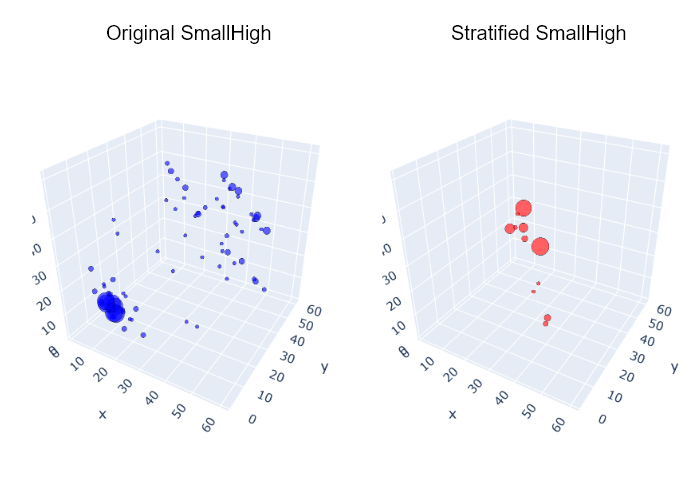

In [ ]:
process_high_school_hypergraph(60)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 60 nodes: [2, 10, 14, 18, 23, 24, 28, 35, 45, 48, 49, 56, 65, 66, 73, 85, 86, 87, 100, 101, 108, 121, 125, 126, 131, 134, 143, 148, 151, 153, 158, 167, 169, 170, 173, 174, 177, 179, 187, 188, 189, 190, 211, 218, 220, 229, 233, 244, 256, 259, 260, 262, 266, 282, 284, 303, 321, 323, 325, 327]

Filtered dataset statistics:
Number of timestamped simplices: 6671
Number of unique node IDs: 58
Simplex size distribution:
  Size 2: 6389 simplices
  Size 3: 277 simplices
  Size 4: 5 simplices
Parsed 6671 simplices
First few simplices:
  Simplex 1 (time 1385982020): [23, 24]
  Simplex 2 (time 1385982040): [23, 24]
  Simplex 3 (time 1385982060): [23, 24]
  Simplex 4 (time 1385982080): [28, 85]
  Simplex 5 (time 1385982080): [23, 24]
  Simplex 6 (time 1385982100): [28, 85]
  Simplex 7 (time 1385982100): [23, 24]
  Simplex 8 (time 1385982120): [28, 85]
  Simplex 9 (time 1385982120): [23, 24]
  S

[ Info: Found 10 derivations for stratification.


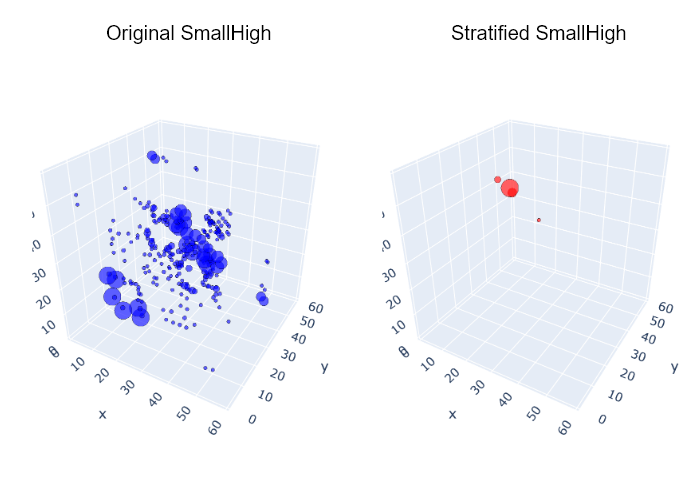

In [ ]:
process_high_school_hypergraph(60)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 60 nodes: [4, 16, 17, 20, 21, 23, 33, 38, 46, 54, 57, 59, 60, 67, 76, 84, 86, 88, 96, 100, 105, 109, 115, 120, 123, 125, 140, 141, 144, 147, 149, 150, 151, 154, 157, 160, 165, 167, 169, 174, 176, 182, 184, 189, 197, 201, 213, 233, 239, 248, 254, 259, 265, 273, 290, 292, 298, 304, 313, 324]

Filtered dataset statistics:
Number of timestamped simplices: 6150
Number of unique node IDs: 60
Simplex size distribution:
  Size 2: 6117 simplices
  Size 3: 33 simplices
Parsed 6150 simplices
First few simplices:
  Simplex 1 (time 1385982020): [60, 59]
  Simplex 2 (time 1385982020): [16, 17]
  Simplex 3 (time 1385982040): [60, 59]
  Simplex 4 (time 1385982060): [60, 59]
  Simplex 5 (time 1385982080): [60, 59]
  Simplex 6 (time 1385982080): [57, 84]
  Simplex 7 (time 1385982100): [60, 59]
  Simplex 8 (time 1385982120): [60, 59]
  Simplex 9 (time 1385982120): [57, 84]
  Simplex 10 (time 13859821

[ Info: Found 10 derivations for stratification.


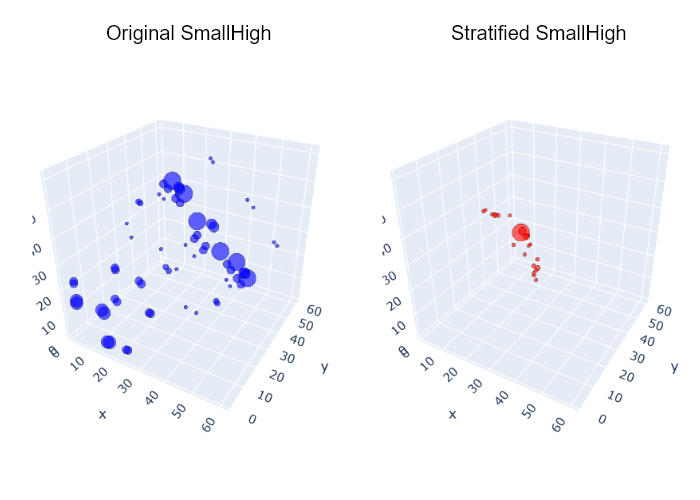

In [ ]:
process_high_school_hypergraph(60)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 90 nodes: [1, 3, 6, 10, 11, 12, 13, 16, 17, 24, 27, 47, 48, 59, 61, 68, 77, 80, 87, 89, 90, 98, 101, 108, 112, 114, 115, 132, 133, 140, 143, 146, 150, 157, 158, 163, 164, 166, 167, 171, 172, 173, 180, 183, 185, 187, 191, 193, 197, 205, 212, 213, 216, 220, 221, 229, 231, 232, 235, 237, 243, 252, 255, 258, 260, 262, 264, 271, 272, 275, 276, 278, 279, 281, 286, 289, 292, 294, 295, 299, 308, 309, 310, 316, 321, 322, 323, 324, 326, 327]

Filtered dataset statistics:
Number of timestamped simplices: 17511
Number of unique node IDs: 90
Simplex size distribution:
  Size 2: 17335 simplices
  Size 3: 174 simplices
  Size 4: 2 simplices
Parsed 17511 simplices
First few simplices:
  Simplex 1 (time 1385982020): [16, 17]
  Simplex 2 (time 1385982020): [13, 12]
  Simplex 3 (time 1385982020): [47, 48]
  Simplex 4 (time 1385982020): [61, 16]
  Simplex 5 (time 1385982040): [13, 12]
  Simplex 6 (tim

[ Info: Found 10 derivations for stratification.


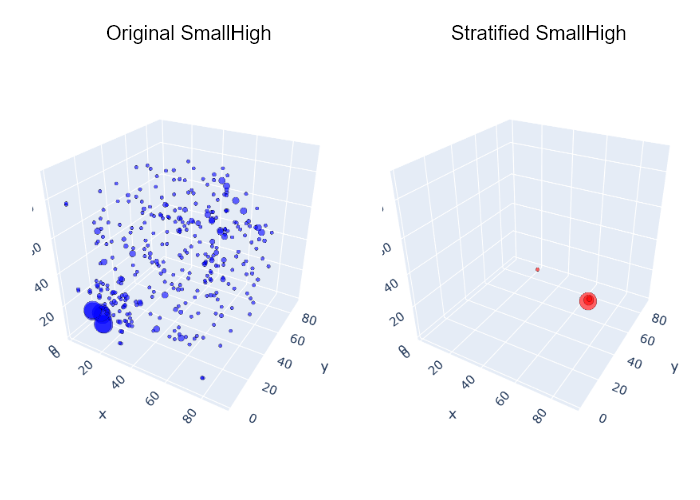

In [ ]:
process_high_school_hypergraph(90)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 90 nodes: [1, 2, 4, 5, 6, 13, 16, 21, 33, 36, 39, 40, 42, 48, 52, 53, 56, 57, 61, 67, 70, 72, 76, 84, 85, 86, 91, 92, 93, 94, 95, 98, 102, 104, 105, 110, 113, 118, 119, 121, 125, 132, 136, 138, 151, 158, 160, 161, 162, 171, 175, 176, 181, 183, 184, 207, 208, 210, 211, 214, 215, 216, 222, 225, 227, 230, 231, 233, 235, 240, 241, 254, 256, 259, 263, 266, 280, 282, 283, 287, 291, 304, 305, 308, 309, 313, 315, 318, 325, 327]

Filtered dataset statistics:
Number of timestamped simplices: 13025
Number of unique node IDs: 87
Simplex size distribution:
  Size 2: 12913 simplices
  Size 3: 111 simplices
  Size 4: 1 simplices
Parsed 13025 simplices
First few simplices:
  Simplex 1 (time 1385982020): [2, 1]
  Simplex 2 (time 1385982020): [40, 39]
  Simplex 3 (time 1385982020): [61, 16]
  Simplex 4 (time 1385982020): [5, 6]
  Simplex 5 (time 1385982040): [2, 1]
  Simplex 6 (time 1385982040): [40

[ Info: Found 10 derivations for stratification.


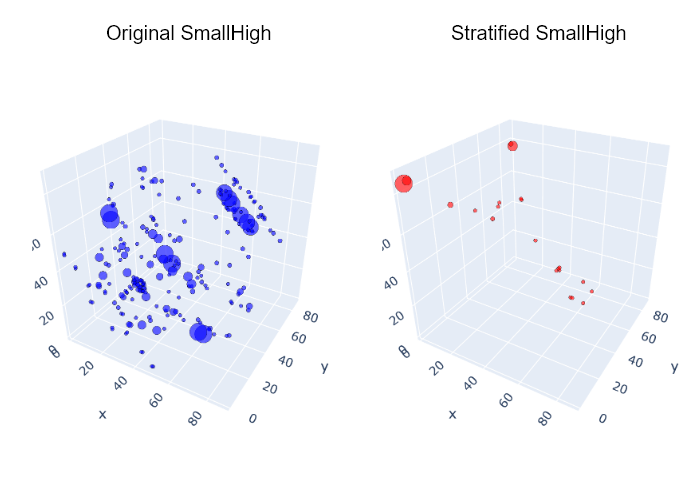

In [ ]:
process_high_school_hypergraph(90)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 90 nodes: [1, 3, 6, 8, 9, 12, 23, 26, 31, 36, 37, 38, 42, 45, 48, 50, 56, 58, 61, 63, 68, 70, 72, 76, 80, 86, 92, 93, 95, 98, 99, 100, 101, 106, 108, 109, 115, 116, 119, 122, 123, 146, 156, 160, 162, 164, 168, 170, 171, 178, 181, 183, 186, 187, 189, 190, 192, 195, 196, 199, 200, 208, 213, 218, 219, 224, 226, 236, 246, 251, 252, 257, 260, 270, 271, 275, 276, 277, 291, 299, 302, 306, 308, 310, 312, 314, 316, 317, 322, 323]

Filtered dataset statistics:
Number of timestamped simplices: 16261
Number of unique node IDs: 90
Simplex size distribution:
  Size 2: 16180 simplices
  Size 3: 80 simplices
  Size 4: 1 simplices
Parsed 16261 simplices
First few simplices:
  Simplex 1 (time 1385982020): [37, 36]
  Simplex 2 (time 1385982020): [36, 38]
  Simplex 3 (time 1385982040): [37, 70]
  Simplex 4 (time 1385982060): [37, 70]
  Simplex 5 (time 1385982120): [37, 70]
  Simplex 6 (time 1385982140

[ Info: Found 10 derivations for stratification.


4613.822471 seconds (2.42 G allocations: 2.333 TiB, 3.03% gc time, 0.25% compilation time: 3% of which was recompilation)
✅ SmallHigh stratification complete!


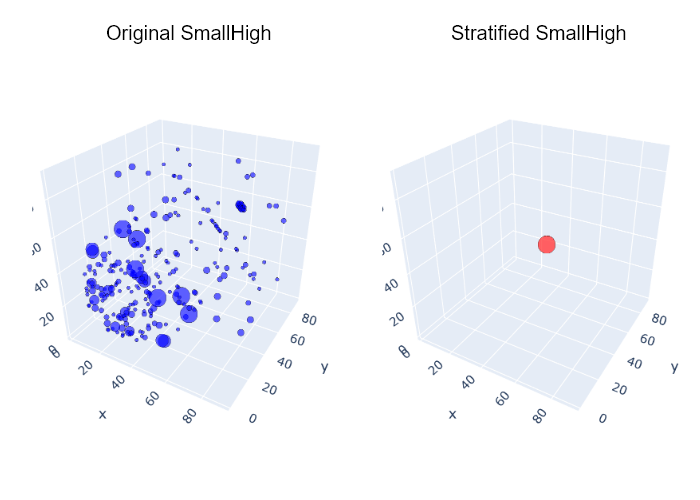

In [4]:
process_high_school_hypergraph(90)

In [5]:
process_high_school_hypergraph(150)

Total number of simplices: 172035
Total node entries: 352718
Total timestamps: 172035
Filtering to random 150 nodes: [2, 8, 12, 13, 15, 18, 19, 20, 21, 22, 23, 25, 26, 30, 31, 32, 33, 34, 35, 36, 42, 44, 45, 46, 47, 49, 51, 54, 57, 59, 65, 66, 67, 73, 74, 75, 77, 78, 81, 85, 94, 95, 96, 97, 98, 100, 101, 103, 104, 106, 107, 108, 109, 111, 117, 118, 122, 124, 126, 127, 128, 131, 133, 140, 145, 148, 149, 150, 152, 153, 154, 155, 156, 157, 159, 163, 166, 168, 169, 171, 172, 173, 175, 176, 177, 178, 182, 183, 185, 186, 187, 188, 191, 192, 194, 195, 196, 198, 200, 201, 203, 204, 205, 207, 208, 212, 216, 217, 224, 225, 226, 230, 235, 237, 239, 240, 244, 247, 249, 251, 254, 255, 258, 259, 260, 262, 264, 266, 267, 268, 270, 271, 275, 283, 284, 285, 288, 289, 290, 291, 296, 297, 299, 302, 309, 313, 315, 317, 325, 326]

Filtered dataset statistics:
Number of timestamped simplices: 39158
Number of unique node IDs: 150
Simplex size distribution:
  Size 2: 37655 simplices
  Size 3: 1464 simplices
 

LoadError: OutOfMemoryError()

In [ ]:
process_high_school_hypergraph(150)

In [ ]:
process_high_school_hypergraph(150)

In [ ]:
process_high_school_hypergraph(200)

In [ ]:
process_high_school_hypergraph(200)

In [ ]:
process_high_school_hypergraph(200)